<a href="https://colab.research.google.com/github/snehatanti/interns-code/blob/main/binod_da_bio_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
files="E://colab practice//ridge data.xlsx"
df1=pd.read_excel("/content/ridge data.xlsx")
df1.head()

,Pollinators,16.30-18.30,18.30-20.30,20.30-22.30,22.30-0.30,0.30-2.30,2.30-4.30,4.30-6.30
0,Amata passalis,5,3,0,0,0,0,2
1,Bastilla simillima,0,1,7,9,6,2,0
2,Botyodesasialis,0,1,5,4,4,2,0
3,Chabulaacamasalis,0,3,3,2,1,0,0
4,Diaphania indica,5,8,16,15,9,3,0


In [27]:
#code for linear regression and multiple linear linear regression

import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

# Assuming 'df1' is your DataFrame

# Simple Linear Regression
# Let's predict '20.30-22.30' based on '16.30-18.30'
X = df1[['16.30-18.30']]  # Independent variable
y = df1['20.30-22.30']  # Dependent variable

# Add a constant to the independent variable for the intercept term
X = sm.add_constant(X)

# Fit the linear regression model
model_slr = sm.OLS(y, X).fit()

# Print the model summary
print("Simple Linear Regression Results:")
print(model_slr.summary())


# Multiple Linear Regression
# Predict '20.30-22.30' based on multiple time slots
X_multiple = df1[['16.30-18.30', '18.30-20.30','22.30-0.30']] # Independent variables
y_multiple = df1['20.30-22.30'] # Dependent Variable

# Add a constant to the independent variables
X_multiple = sm.add_constant(X_multiple)

# Fit the multiple linear regression model
model_mlr = sm.OLS(y_multiple, X_multiple).fit()

# Print the model summary
print("\nMultiple Linear Regression Results:")
print(model_mlr.summary())


Simple Linear Regression Results:
                            OLS Regression Results                            
Dep. Variable:            20.30-22.30   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     3.271
Date:                Sun, 27 Oct 2024   Prob (F-statistic):             0.0805
Time:                        06:05:52   Log-Likelihood:                -97.123
No. Observations:                  32   AIC:                             198.2
Df Residuals:                      30   BIC:                             201.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           

In [18]:
#code for simpsons index for all the columns

import pandas as pd

def simpsons_index(series):
    """
    Calculate the Simpson's Diversity Index for a pandas Series.
    """
    # Calculate proportions of each value in the series
    proportions = series.value_counts(normalize=True)

    # Calculate Simpson's Index (1 - D)
    simpson_index_value = 1 - proportions.apply(lambda p: p**2).sum()

    return simpson_index_value

# Calculate Simpson's Index for each column
simpson_indices = {}
for column in df1.columns:
    if column != 'Pollinators':  # Skip the non-numeric column
        simpson_indices[column] = simpsons_index(df1[column])

# Print the results
print("Simpson's Index for each column:")
for col, value in simpson_indices.items():
    print(f"{col}: {value}")

Simpson's Index for each column:
16.30-18.30: 0.87890625
18.30-20.30: 0.8828125
20.30-22.30: 0.892578125
22.30-0.30: 0.8828125
0.30-2.30: 0.724609375
2.30-4.30: 0.60546875
4.30-6.30: 0.173828125


In [16]:
# Iterate through each row (index) of the DataFrame
for index, row in df1.iterrows():
    # Extract activity counts for different time intervals
    activity_16_18 = row['16.30-18.30']
    activity_18_20 = row['18.30-20.30']
    activity_20_22 = row['20.30-22.30']
    activity_22_00 = row['22.30-0.30']
    activity_00_02 = row['0.30-2.30']
    activity_02_04 = row['2.30-4.30']
    activity_04_06 = row['4.30-6.30']

    # Calculate total activity for this pollinator
    total_activity = activity_16_18 + activity_18_20 + activity_20_22 + activity_22_00 + activity_00_02 + activity_02_04 + activity_04_06

    # Print the total activity
    print(f"Total activity for {row['Pollinators']}: {total_activity}")

Total activity for Amata passalis: 10
Total activity for Bastilla simillima: 25
Total activity for Botyodesasialis: 16
Total activity for Chabulaacamasalis: 9
Total activity for Diaphania indica: 56
Total activity for Diaphniahyalinata: 44
Total activity for Elophilasp.: 23
Total activity for Glyphodes bicolour: 14
Total activity for Glyphodesbivitralis: 14
Total activity for Herpetogammasp.: 23
Total activity for Hippotioncelerio: 46
Total activity for Hydrididsornatalis: 11
Total activity for Lerema accius: 28
Total activity for Nausionaepueritia: 7
Total activity for Paraponyxvillidalis: 10
Total activity for Parotis marginata: 21
Total activity for Poliobotysalbactis: 29
Total activity for Pycnormoncribata: 15
Total activity for Spoladearecurvalis: 16
Total activity for Suastsgremius: 17
Total activity for Theretrasilhetensis: 17
Total activity for Trichoplusiasp.: 6
Total activity for Camponotuscompressus: 36
Total activity for Diacammarugosum: 5
Total activity for Monomorium mini

In [3]:


import numpy as np

# Function to calculate Shannon diversity index
def shannon_diversity(counts):
  """Calculates the Shannon diversity index.

  Args:
    counts: A list or numpy array of counts for each species.

  Returns:
    The Shannon diversity index.
  """
  total_counts = np.sum(counts)
  probabilities = counts / total_counts
  shannon_index = -np.sum(probabilities * np.log(probabilities))
  return shannon_index

# Assuming your data is in a dataframe called df1

# Calculate Shannon diversity for each time interval
shannon_diversity_per_interval = []
for col in df1.columns[1:]:
  # Calculate the Shannon diversity for the current interval
  shannon_index = shannon_diversity(df1[col])
  shannon_diversity_per_interval.append(shannon_index)

# Print the Shannon diversity for each interval
print("Shannon diversity per interval:")
for i, col in enumerate(df1.columns[1:]):
  print(f"{col}: {shannon_diversity_per_interval[i]:.2f}")



Shannon diversity per interval:
16.30-18.30: 3.04
18.30-20.30: 3.24
20.30-22.30: 3.10
22.30-0.30: 2.91
0.30-2.30: 2.55
2.30-4.30: 2.38
4.30-6.30: 1.04


In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Basic descriptive statistics for each column
print(df1.describe())

# Visualizations for the numerical features
# 1. Histogram for each time period
for column in df1.columns[1:]:
    plt.figure()
    plt.hist(df1[column], bins=10)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {column}")
    plt.show()

# 2. Boxplot for each time period
for column in df1.columns[1:]:
    plt.figure()
    sns.boxplot(x=df1[column])
    plt.xlabel(column)
    plt.title(f"Boxplot of {column}")
    plt.show()

# 3. Pairwise correlation matrix for all time periods
correlation_matrix = df1.iloc[:, 1:].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Time Periods")
plt.show()

# 4. Correlation between total number of pollinators and the time periods
df1['Total_Pollinators'] = df1.iloc[:, 1:].sum(axis=1)
for column in df1.columns[1:-1]:
    plt.figure()
    plt.scatter(df1[column], df1['Total_Pollinators'])
    plt.xlabel(column)
    plt.ylabel("Total Pollinators")
    plt.title(f"Correlation between {column} and Total Pollinators")
    plt.show()

# Additional analysis
# 1. Find the average number of pollinators for each time period
avg_pollinators_per_period = df1.iloc[:, 1:].mean()
print(f"Average pollinators per time period:\n{avg_pollinators_per_period}")

# 2. Find the most active time period based on the average number of pollinators
most_active_period = avg_pollinators_per_period.idxmax()
print(f"Most active time period: {most_active_period}")

# Note: You may need to adapt the visualizations based on your specific needs and interests.


In [4]:
print(df1.describe())

       16.30-18.30  18.30-20.30  20.30-22.30  22.30-0.30  0.30-2.30  \
count    32.000000    32.000000     32.00000   32.000000   32.00000   
mean      4.312500     5.125000      5.65625    4.250000    2.53125   
std       4.019609     3.661042      5.38582    4.859311    3.62771   
min       0.000000     1.000000      0.00000    0.000000    0.00000   
25%       1.000000     2.750000      2.00000    1.000000    0.00000   
50%       3.000000     5.000000      4.00000    3.000000    1.00000   
75%       6.000000     6.250000      7.00000    5.250000    4.00000   
max      17.000000    16.000000     21.00000   18.000000   13.00000   

       2.30-4.30  4.30-6.30  
count  32.000000  32.000000  
mean    1.000000   0.125000  
std     1.606439   0.421212  
min     0.000000   0.000000  
25%     0.000000   0.000000  
50%     0.000000   0.000000  
75%     2.000000   0.000000  
max     7.000000   2.000000  


In [5]:
avg_pollinators_per_period = df1.iloc[:, 1:].mean()
print(f"Average pollinators per time period:\n{avg_pollinators_per_period}")

Average pollinators per time period:
16.30-18.30    4.31250
18.30-20.30    5.12500
20.30-22.30    5.65625
22.30-0.30     4.25000
0.30-2.30      2.53125
2.30-4.30      1.00000
4.30-6.30      0.12500
dtype: float64


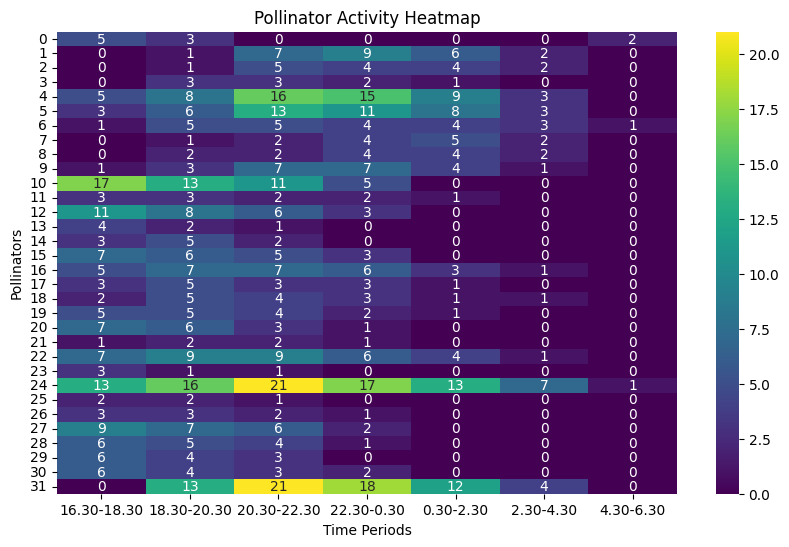

In [6]:


# Import necessary libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your data is in a Pandas DataFrame named 'df1'

# Prepare the data for the heatmap by selecting the relevant columns
heatmap_data = df1.iloc[:, 1:]

# Create the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='viridis')

# Customize the plot (optional)
plt.title('Pollinator Activity Heatmap')
plt.xlabel('Time Periods')
plt.ylabel('Pollinators')

# Display the plot
plt.show()



In [7]:
df1.isnull().sum()

,0
Pollinators,0
16.30-18.30,0
18.30-20.30,0
20.30-22.30,0
22.30-0.30,0
0.30-2.30,0
2.30-4.30,0
4.30-6.30,0


In [8]:
import altair as alt

df1_melted = df1.melt(id_vars=['Pollinators'], value_vars=['16.30-18.30', '18.30-20.30', '20.30-22.30', '22.30-0.30', '0.30-2.30', '2.30-4.30', '4.30-6.30'],
                      var_name='Time Window', value_name='Count')

alt.Chart(df1_melted).mark_rect().encode(
    x='Time Window:O',
    y='Pollinators:O',
    color='Count:Q'
)

alt.Chart(...)

In [9]:
files="E://colab practice//bottle data.xlsx"
df2=pd.read_excel("/content/bottle data.xlsx")
df2.head()

,Pollinators,16.30-18.30,18.30-20.30,20.30-22.30,22.30-0.30,0.30-2.30,2.30-4.30,4.30-6.30
0,Agathodesostentalis,5,8,13,11,3,0,0
1,Agrius convolvuli,7,4,0,0,0,0,0
2,Anadevidiapeponis,2,5,9,4,1,0,0
3,Diaphania indica,3,13,17,9,4,4,0
4,Dysgonia sp.,1,4,6,11,5,3,0


In [28]:
#code for linear regression and multiple linear linear regression

import statsmodels.api as sm
import pandas as pd
import numpy as np

#Rename the columns for easier use
df2 = df2.rename(columns={'16.30-18.30': 'Time1', '18.30-20.30': 'Time2', '20.30-22.30': 'Time3'})

#Linear Regression
#Define predictor (X) and response (y) variables
X = df2['Time1']  #Use Time1 for simple linear regression
y = df2['Time2']

#Add a constant to the predictor variable (intercept term)
X = sm.add_constant(X)

#Fit the linear regression model
model = sm.OLS(y, X).fit()

#Print the model summary
print("Linear Regression Results:")
print(model.summary())

#Multiple Linear Regression
#Define multiple predictor variables (X) and the response variable (y)
X = df2[['Time1', 'Time2']]
y = df2['Time3']

#Add a constant to the predictor variables (intercept term)
X = sm.add_constant(X)

#Fit the multiple linear regression model
model = sm.OLS(y,X).fit()

#Print the model summary
print("\nMultiple Linear Regression Results:")
print(model.summary())

Linear Regression Results:
                            OLS Regression Results                            
Dep. Variable:                  Time2   R-squared:                       0.536
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     2.308
Date:                Sun, 27 Oct 2024   Prob (F-statistic):              0.268
Time:                        06:07:25   Log-Likelihood:                -6.6468
No. Observations:                   4   AIC:                             17.29
Df Residuals:                       2   BIC:                             16.07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0000    

/usr/local/lib/python3.10/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/usr/local/lib/python3.10/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [19]:
#code for simpsons index for all the columns

import pandas as pd

def simpsons_index(series):
    """
    Calculate the Simpson's Diversity Index for a pandas Series.
    """
    # Calculate the proportion of each species
    proportions = series.value_counts(normalize=True)

    # Calculate the squared proportions
    squared_proportions = proportions ** 2

    # Sum the squared proportions
    sum_squared_proportions = squared_proportions.sum()

    # Return the Simpson's index (1 - D)
    return 1 - sum_squared_proportions

# Iterate through the columns and calculate the Simpson's index
for col in df2.columns[1:]:  # Exclude the first column (Pollinators) which is not numeric

    # Calculate Simpson's index for current column
    simpson = simpsons_index(df2[col])
    print(f"Simpson's index for column '{col}': {simpson}")

Simpson's index for column '16.30-18.30': 0.865
Simpson's index for column '18.30-20.30': 0.88
Simpson's index for column '20.30-22.30': 0.9099999999999999
Simpson's index for column '22.30-0.30': 0.8200000000000001
Simpson's index for column '0.30-2.30': 0.6549999999999999
Simpson's index for column '2.30-4.30': 0.41500000000000004
Simpson's index for column '4.30-6.30': 0.705


In [10]:
import altair as alt

df2_melted = df2.melt(id_vars=['Pollinators'], value_vars=['16.30-18.30', '18.30-20.30', '20.30-22.30', '22.30-0.30', '0.30-2.30', '2.30-4.30', '4.30-6.30'],
                      var_name='Time Window', value_name='Count')

alt.Chart(df2_melted).mark_rect().encode(
    x='Time Window:O',
    y='Pollinators:O',
    color='Count:Q'
)

alt.Chart(...)

In [11]:


import numpy as np

# Function to calculate Shannon diversity index
def shannon_diversity(counts):
  """Calculates the Shannon diversity index.

  Args:
    counts: A list or numpy array of counts for each species.

  Returns:
    The Shannon diversity index.
  """
  total_counts = np.sum(counts)
  probabilities = counts / total_counts
  shannon_index = -np.sum(probabilities * np.log(probabilities))
  return shannon_index

# Assuming your data is in a dataframe called df1

# Calculate Shannon diversity for each time interval
shannon_diversity_per_interval = []
for col in df2.columns[1:]:
  # Calculate the Shannon diversity for the current interval
  shannon_index = shannon_diversity(df2[col])
  shannon_diversity_per_interval.append(shannon_index)

# Print the Shannon diversity for each interval
print("Shannon diversity per interval:")
for i, col in enumerate(df2.columns[1:]):
  print(f"{col}: {shannon_diversity_per_interval[i]:.2f}")

Shannon diversity per interval:
16.30-18.30: 2.72
18.30-20.30: 2.73
20.30-22.30: 2.53
22.30-0.30: 2.36
0.30-2.30: 1.98
2.30-4.30: 1.56
4.30-6.30: 2.09


In [12]:
files="E:\colab practice\ridge no.xlsx"
df3=pd.read_excel("/content/ridge no.xlsx")
df3.head()

,Insect Order,June,July,August,September,October
0,Lepidoptera,356,401,457,463,376
1,Hymenoptera,98,123,143,155,111
2,Coleoptera,53,56,68,71,52
3,Blattodea,34,49,53,51,45
4,Orthoptera,11,13,15,21,15


In [13]:
files="E:\colab practice\bottle no.xlsx"
df4=pd.read_excel("/content/bottle no.xlsx")
df4.head()

,Insect Order,June,July,August,September,October
0,Lepodoptera,201,243,253,265,233
1,Coleoptera,197,201,212,215,197
2,Hymenoptera,51,55,57,65,49
3,Hemiptera,41,48,52,59,47
4,Blattodea,29,31,35,37,30


In [14]:


#code for linear regression and multiple linear linear regression

import altair as alt
import pandas as pd

# Assuming both dataframes have the same columns
# Melt dataframes into long format
df4_long = pd.melt(df4, id_vars=['Insect Order'], var_name='Month', value_name='Count')
# Assuming df3 exists and has the same structure
df3_long = pd.melt(df3, id_vars=['Insect Order'], var_name='Month', value_name='Count')

# Create a chart with different color for each dataset
chart = alt.Chart(df4_long).mark_bar().encode(
    x=alt.X('Month:N', sort=['June', 'July', 'August', 'September', 'October']),
    y='Count:Q',
    color='Insect Order',
    column='Insect Order'
).properties(title='Insect Counts (df4)')


# Create a chart for df3
chart_df3 = alt.Chart(df3_long).mark_bar().encode(
    x=alt.X('Month:N', sort=['June', 'July', 'August', 'September', 'October']),
    y='Count:Q',
    color='Insect Order',
    column='Insect Order'
).properties(title='Insect Counts (df3)')

# Display both charts
chart | chart_df3


alt.HConcatChart(...)